In [4]:
# Load the tidyverse packages

if (!require("tidyverse")) {
    install.packages("tidyverse")
}

library(tidyverse)

# Download and read the data
dt <- read_delim("https://github.com/febse/data/raw/refs/heads/main/econ/invoices.txt")

dt |> head()

Rows: 30 Columns: 3
── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
dbl (3): Day, Invoices, Time

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


Day,Invoices,Time
<dbl>,<dbl>,<dbl>
1,149,2.1
2,60,1.8
3,188,2.3
4,23,0.8
5,201,2.7
6,58,1.0


Variables description:

-   `Day` (numeric): day (1 to 30)
-   `Invoices` (numeric): number of invoices
-   `Time` (numeric): Time needed to process the invoices (hours)
  

In [6]:
dt |> summary()

      Day           Invoices          Time      
 Min.   : 1.00   Min.   : 23.0   Min.   :0.800  
 1st Qu.: 8.25   1st Qu.: 62.5   1st Qu.:1.500  
 Median :15.50   Median :127.5   Median :2.000  
 Mean   :15.50   Mean   :130.0   Mean   :2.110  
 3rd Qu.:22.75   3rd Qu.:189.5   3rd Qu.:2.775  
 Max.   :30.00   Max.   :289.0   Max.   :4.100  

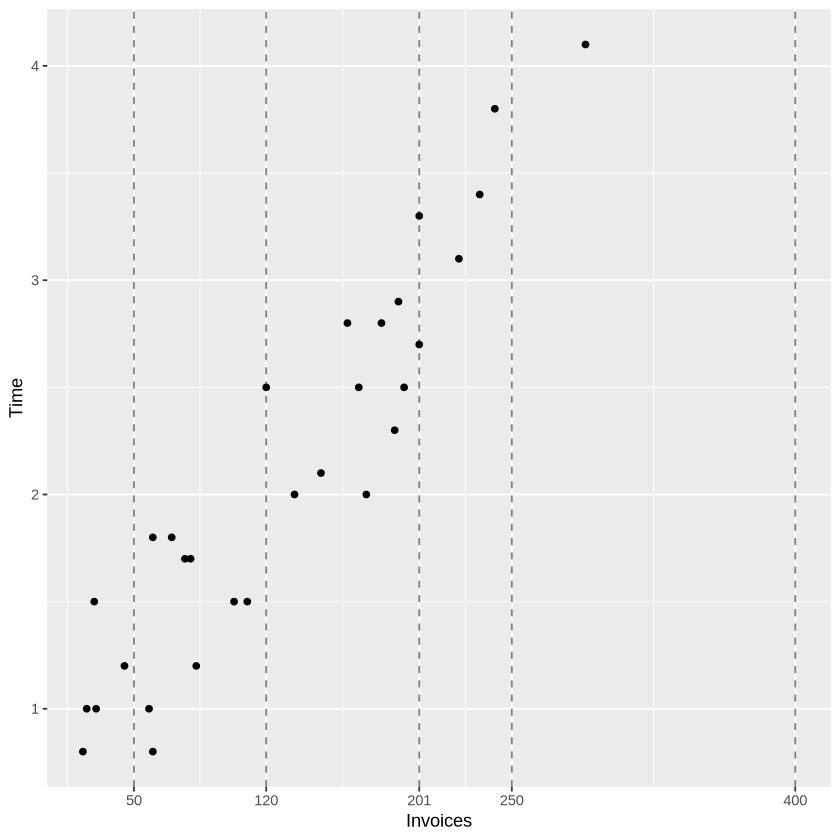

In [7]:
dt %>%
  ggplot(aes(x = Invoices, y = Time)) +
    geom_point() +
    geom_vline(xintercept = c(50, 120, 201, 250, 400), lty = 2, alpha = 0.5) +
    scale_x_continuous(breaks = c(50, 120, 201, 250, 400))

In [ ]:
# Create two new columns for the predicted time and for the residuals of this prediction


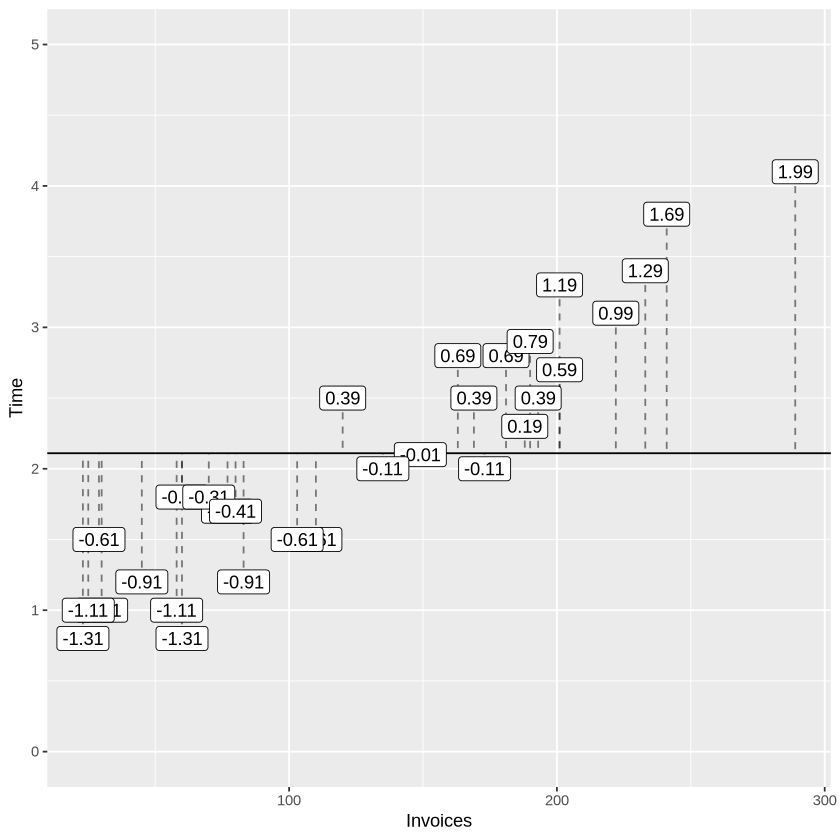

In [8]:
dt |>
    mutate(
        Time_predicted = mean(Time),
        residuals = Time - Time_predicted
    ) |>
    ggplot(aes(x = Invoices, y = Time)) +
    geom_point() +
    geom_hline(yintercept = mean(dt$Time), lty = 1) +
    ylim(c(0, 5)) +
    geom_segment(
        aes(
            xend = Invoices,
            yend = mean(dt$Time)
            ), 
            lty = 2,
            alpha = 0.5
        ) +
    geom_label(aes(label = round(residuals, 2)))